## Import packages and libraries

In [4]:
import os
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

E0000 00:00:1774562072.893442 4001026 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1774562072.893613 4001026 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1774562072.893614 4001026 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1774562072.893616 4001026 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1774562072.893621 4001026 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


## Assumptions and references for task A

### Demand
Source: https://www.energidataservice.dk/tso-electricity/productionconsumptionsettlement

Hourly electricity demand for DK1 is based on 2025 data from Energinet. The variable *GrossConsumptionMWh* is used as total demand. Demand is assumed to be inelastic and must be met in every hour.

### Renewable generation profiles

Due to lack of installed capacity data, hourly generation time series are normalized by their annual maximum to approximate availability profiles:

$$
p_{\text{max\_pu}, t} = \frac{\text{generation}_t}{\max(\text{generation})}
$$

This provides a simplified representation of temporal variability in renewable generation.

### Cost assumptions

Source: https://github.com/PyPSA/technology-data

Technology costs (CAPEX, FOM, VOM, efficiency) are taken from the PyPSA Technology Data for 2030. Investment costs are converted from EUR/kW to EUR/MW and annualized using a discount rate of 7%.

$$
\text{annualized cost} = \text{CAPEX} \cdot \frac{r}{1 - (1 + r)^{-n}} + \text{FOM}
$$

### Marginal costs

Renewable generators are assumed to have zero marginal cost:

$$
MC_{\text{RES}} \approx 0
$$

For OCGT, marginal cost is calculated as:

$$
MC = \frac{P_{\text{gas}}}{\eta} + \frac{P_{\text{CO2}} \cdot I_{\text{CO2}}}{\eta} + VOM
$$

where fuel price is assumed to be $40\ \mathrm{€/MWh_{th}}$ and CO$_2$ price $80\ \mathrm{€/tCO_2}$.

### Technological assumptions

The model includes solar PV, onshore wind, offshore wind, and OCGT. Capacity expansion is allowed for all technologies, and the system is modeled as a single-node network with perfect foresight.

### Assumptions for Task B (interannual variability)

To assess the sensitivity of optimal capacities to interannual variability in renewable generation, the model is solved for multiple weather years (2020–2025).

The following assumptions are applied:

- **Fixed demand:** Electricity demand is kept constant and based on the 2025 demand profile in all model runs. This isolates the effect of weather variability.

- **Variable renewable profiles:** Solar and wind availability profiles are constructed separately for each weather year using historical generation data and normalized to obtain p_max_pu.

- **Constant cost assumptions:** All technology cost parameters (CAPEX, FOM, VOM, efficiency) are assumed identical across all years.

- **Identical model structure:** The system configuration, technologies, and modeling assumptions are unchanged across runs.

- **No structural changes:** No changes in technology availability, fuel prices, or CO$_2$ prices are considered between years.

### Introduction and assumptions for Task C (Adding storage technology)

The base model used is the same as in Task B but with battery stroage added.

Battery costs are added in the code for Task A but is first used in Task C.

The following assumptions are applied:

- **Battery Capacity** Maximum state of charge capacity in terms of hours at full output power capacity is assumed at 4 hours.

- **Marginal Costs** Marginal costs of battery is assumed to be zero.


## TASK A

In [5]:
# Prepare data
pd.options.future.infer_string = False

df = pd.read_csv("Data/ProductionConsumptionSettlement.csv", sep=";", decimal=",")
costs = pd.read_csv("Data/costs_PyPSA.csv")

# Parse datetime
df["HourUTC"] = pd.to_datetime(df["HourUTC"], utc=True)
df["HourUTC"] = df["HourUTC"].dt.tz_convert(None)

# Set index
df = df.set_index("HourUTC").sort_index()

# Keep only 2025
df = df.loc["2025-01-01 00:00":"2025-12-31 23:00"]

# Keep only 2030
costs = costs[costs["year"] == 2030].copy()
costs["value"] = pd.to_numeric(costs["value"], errors="coerce")
costs = costs.set_index(["technology", "parameter"])

"""
print(df.head())
print(df.columns.tolist())
print(df.shape)
"""

'\nprint(df.head())\nprint(df.columns.tolist())\nprint(df.shape)\n'

In [6]:
# Demand
load_dk1 = df["GrossConsumptionMWh"].astype(float)

# Onshore wind
onshore_gen = (
    df["OnshoreWindLt50kW_MWh"].astype(float)
    + df["OnshoreWindGe50kW_MWh"].astype(float)
)

# Offshore wind
offshore_gen = (
    df["OffshoreWindLt100MW_MWh"].astype(float)
    + df["OffshoreWindGe100MW_MWh"].astype(float)
)

# Solar
solar_gen = (
    df["SolarPowerLt10kW_MWh"].astype(float)
    + df["SolarPowerGe10Lt40kW_MWh"].astype(float)
    + df["SolarPowerGe40kW_MWh"].astype(float)
)

In [7]:
# Availability profiles
def make_profile(series):
    series = series.fillna(0.0)
    max_val = series.max()
    if max_val <= 0:
        raise ValueError(f"{series.name} has no positive values.")
    return series / max_val

solar_cf = make_profile(solar_gen)
onshore_cf = make_profile(onshore_gen)
offshore_cf = make_profile(offshore_gen)

"""
print(solar_cf.describe())
print(onshore_cf.describe())
print(offshore_cf.describe())
"""

'\nprint(solar_cf.describe())\nprint(onshore_cf.describe())\nprint(offshore_cf.describe())\n'

In [8]:
# Shared costs for all tasks
def get_cost(tech, param):
    return float(costs.loc[(tech, param), "value"])

# Solar
solar_capex = get_cost("solar", "investment") * 1000  # €/MW
solar_lifetime = get_cost("solar", "lifetime")
solar_fom_percent = get_cost("solar", "FOM")

solar_fom = solar_fom_percent / 100 * solar_capex
solar_marginal_cost = 0


# Onshore wind
onshore_capex = get_cost("onwind", "investment") * 1000
onshore_lifetime = get_cost("onwind", "lifetime")
onshore_fom = get_cost("onwind", "FOM") / 100 * onshore_capex
onshore_marginal_cost = 0


# Offshore wind
offshore_capex = get_cost("offwind", "investment") * 1000
offshore_lifetime = get_cost("offwind", "lifetime")
offshore_fom = get_cost("offwind", "FOM") / 100 * offshore_capex
offshore_marginal_cost = 0


# Gas
ocgt_capex = get_cost("OCGT", "investment") * 1000
ocgt_lifetime = get_cost("OCGT", "lifetime")
ocgt_fom = get_cost("OCGT", "FOM") / 100 * ocgt_capex
ocgt_efficiency = get_cost("OCGT", "efficiency")
ocgt_vom = get_cost("OCGT", "VOM")

# Battery - Used from task C
battery_duration = 4.0 # Assumption: Maximum state of charge capacity in terms of hours at full output power capacity

battery_inverter_efficiency_store = get_cost("battery inverter","efficiency") # Efficiency of storage on the way into the storage
battery_inverter_efficiency_dispatch = get_cost("battery inverter","efficiency") # Efficiency of storage on the way out of the storage
battery_inverter_capex = get_cost("battery inverter","investment") * 1000
battery_inverter_fom = get_cost("battery inverter","FOM") / 100 * battery_inverter_capex
battery_inverter_lifetime = get_cost("battery inverter","lifetime")

battery_storage_capex = get_cost("battery storage","investment") * 1000
battery_storage_lifetime = get_cost("battery storage","lifetime")

battery_marginal_cost = 0.0


# Assumptions for fuel and CO2
gas_price = 40.0          # €/MWh_th
co2_price = 80.0          # €/tCO2
co2_intensity = 0.202     # tCO2/MWh_th

ocgt_marginal_cost = (
    gas_price / ocgt_efficiency
    + co2_price * co2_intensity / ocgt_efficiency
    + ocgt_vom
)

# Annulaize the costs
def annuity(r, n):
    return r / (1 - (1 + r) ** (-n))

def annualize_capex(capex, lifetime, fom=0, discount_rate=0.07):
    return capex * annuity(discount_rate, lifetime) + fom

solar_annualized_cost = annualize_capex(solar_capex, solar_lifetime, solar_fom)
onshore_annualized_cost = annualize_capex(onshore_capex, onshore_lifetime, onshore_fom)
offshore_annualized_cost = annualize_capex(offshore_capex, offshore_lifetime, offshore_fom)
ocgt_annualized_cost = annualize_capex(ocgt_capex, ocgt_lifetime, ocgt_fom)
battery_inverter_annualized_cost = annualize_capex(battery_inverter_capex, battery_inverter_lifetime, battery_inverter_fom)
battery_storage_annualized_cost = annualize_capex(battery_storage_capex, battery_storage_lifetime)
battery_annualized_cost = battery_inverter_annualized_cost +battery_storage_annualized_cost

print("Marginal costs:")
print("Solar:", solar_marginal_cost)
print("Onshore wind:", onshore_marginal_cost)
print("Offshore wind:", offshore_marginal_cost)
print("OCGT:", ocgt_marginal_cost)
print("Battery:", battery_marginal_cost)
print("--------------------------------------------------------------------")
print("Annualized costs:")
print("solar_annualized_cost:", solar_annualized_cost)
print("onshore_annualized_cost:", onshore_annualized_cost)
print("offshore_annualized_cost:", offshore_annualized_cost)
print("ocgt_annualized_cost:", ocgt_annualized_cost)
print("battery_inverter_annualized_cost:", battery_inverter_annualized_cost)
print("battery_storage_annualized_cost:", battery_storage_annualized_cost)
print("battery_annualized_cost:", battery_annualized_cost)

Marginal costs:
Solar: 0
Onshore wind: 0
Offshore wind: 0
OCGT: 147.0
Battery: 0.0
--------------------------------------------------------------------
Annualized costs:
solar_annualized_cost: 76486.31233239936
onshore_annualized_cost: 136428.03241482674
offshore_annualized_cost: 295041.146434988
ocgt_annualized_cost: 47234.561404444474
battery_inverter_annualized_cost: 51125.49248047808
battery_storage_annualized_cost: 21080.567942593243
battery_annualized_cost: 72206.06042307132


In [9]:
# Create network
network = pypsa.Network()

# Hourly snapshots for full year 2025
snapshots = pd.date_range("2025-01-01 00:00", "2025-12-31 23:00", freq="h")
network.set_snapshots(snapshots)

# Make sure time series match snapshots exactly
load_dk1 = load_dk1.reindex(snapshots).ffill().fillna(0).astype(float)
solar_cf = solar_cf.reindex(snapshots).fillna(0).astype(float)
onshore_cf = onshore_cf.reindex(snapshots).fillna(0).astype(float)
offshore_cf = offshore_cf.reindex(snapshots).fillna(0).astype(float)

# Add electricity bus
network.add("Bus", "DK1")

# Load
network.add(
    "Load",
    "DK1_load",
    bus="DK1",
    p_set=load_dk1
)

# Generation
network.add(
    "Generator",
    "solar",
    bus="DK1",
    p_nom_extendable=True,
    p_max_pu=solar_cf,
    capital_cost=solar_annualized_cost,
    marginal_cost=solar_marginal_cost
)

network.add(
    "Generator",
    "onshore_wind",
    bus="DK1",
    p_nom_extendable=True,
    p_max_pu=onshore_cf,
    capital_cost=onshore_annualized_cost,
    marginal_cost=onshore_marginal_cost
)

network.add(
    "Generator",
    "offshore_wind",
    bus="DK1",
    p_nom_extendable=True,
    p_max_pu=offshore_cf,
    capital_cost=offshore_annualized_cost,
    marginal_cost=offshore_marginal_cost
)

network.add(
    "Generator",
    "ocgt",
    bus="DK1",
    p_nom_extendable=True,
    capital_cost=ocgt_annualized_cost,
    marginal_cost=ocgt_marginal_cost,
    efficiency=ocgt_efficiency
)

# Run optimization
network.optimize()

Index(['DK1'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 568.68it/s]
INFO:linopy.io: Writing time: 0.06s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-8yri1otx has 78844 rows; 35044 cols; 140157 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 1e+00]
  Cost    [1e+02, 3e+05]
  Bound   [0e+00, 0e+00]
  RHS     [2e+03, 5e+03]
Presolving model
43792 rows, 35036 cols, 105097 nonzeros  0s
Dependent equations search running on 8759 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
40895 rows, 35036 cols, 99304 nonzeros  0s
Presolve reductions: rows 40895(-37949); columns 35036(-8); nonzeros 99304(-40853) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     1.2602314571e+08 Pr: 8759(9.77059e+06) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 2.57e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      32553     2.5672925595e+09 Pr: 0(0); Du: 0(3.58946e-11) 1.6s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-8yri1otx
Model status        : Optimal
Simplex   iterations: 32553
Objective value     :  2.5672925595e+09
P-D objective error :  3.1575021155e-15
HiGHS run time      :          1.58


('ok', 'optimal')

In [10]:
capacities = network.generators[["p_nom_opt"]]
capacities.columns = ["Capacity (MW)"]

print("\nOptimal capacities:")
print(capacities)


Optimal capacities:
               Capacity (MW)
name                        
solar            3949.711653
onshore_wind     6775.177498
offshore_wind      -0.000000
ocgt             3636.422709


In [11]:
# Prepare plots
os.makedirs("Figures", exist_ok=True)

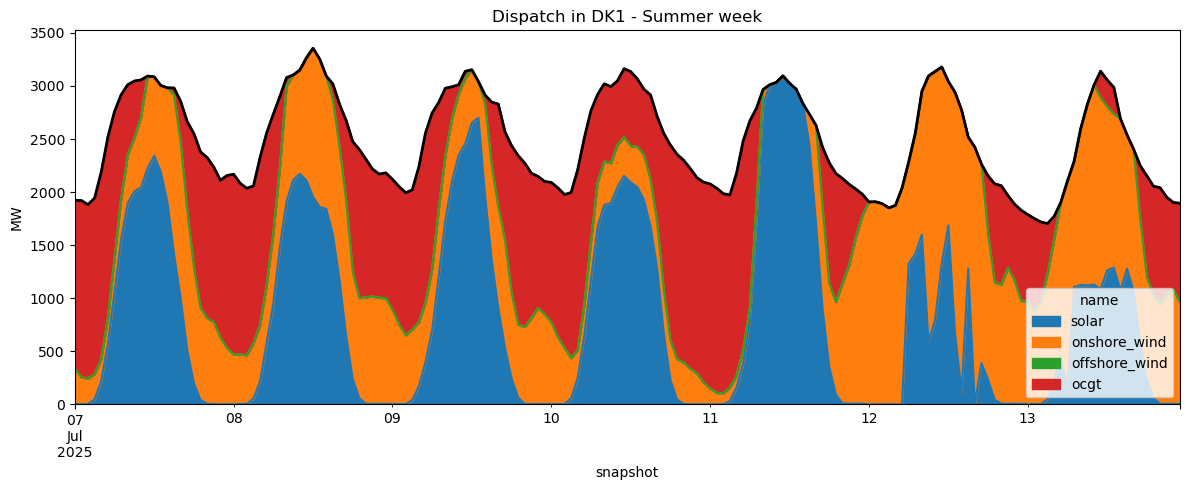

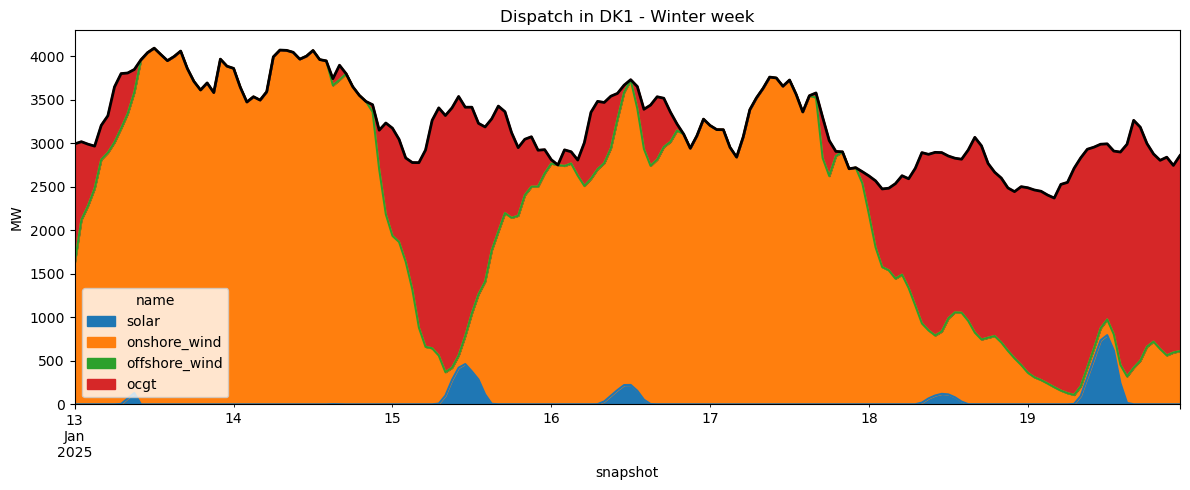

In [12]:
# Dispatch plot
dispatch = network.generators_t.p[["solar", "onshore_wind", "offshore_wind", "ocgt"]]
load = network.loads_t.p["DK1_load"]

summer_week = slice("2025-07-07", "2025-07-13 23:00")
winter_week = slice("2025-01-13", "2025-01-19 23:00")

# Summer
ax = dispatch.loc[summer_week].plot.area(figsize=(12, 5))
load.loc[summer_week].plot(ax=ax, color="black", linewidth=2)

plt.title("Dispatch in DK1 - Summer week")
plt.ylabel("MW")
plt.tight_layout()

plt.savefig("Figures/dispatch_summer.png", dpi=300, bbox_inches="tight")

plt.show()


# Winter
ax = dispatch.loc[winter_week].plot.area(figsize=(12, 5))
load.loc[winter_week].plot(ax=ax, color="black", linewidth=2)

plt.title("Dispatch in DK1 - Winter week")
plt.ylabel("MW")
plt.tight_layout()

plt.savefig("Figures/dispatch_winter.png", dpi=300, bbox_inches="tight")

plt.show()


Annual generation (MWh):
name
solar            3.693109e+06
onshore_wind     1.378046e+07
offshore_wind    0.000000e+00
ocgt             7.953093e+06
dtype: float64


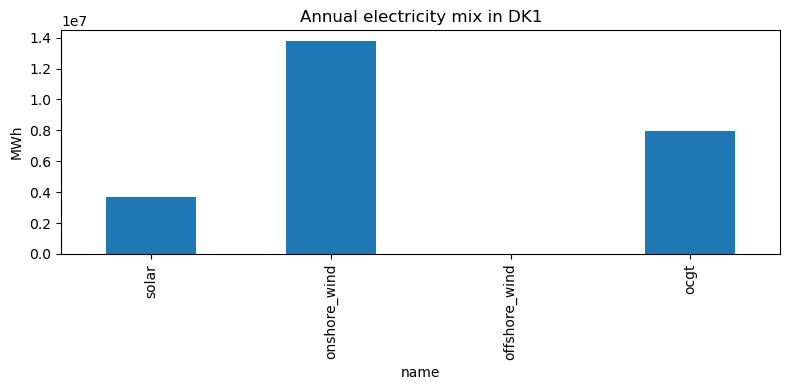

In [13]:
#Annual electricity mix plot
annual_mix = dispatch.sum()

print("\nAnnual generation (MWh):")
print(annual_mix)

annual_mix.plot(kind="bar", figsize=(8, 4))

plt.title("Annual electricity mix in DK1")
plt.ylabel("MWh")
plt.tight_layout()

plt.savefig("Figures/annual_mix.png", dpi=300, bbox_inches="tight")

plt.show()

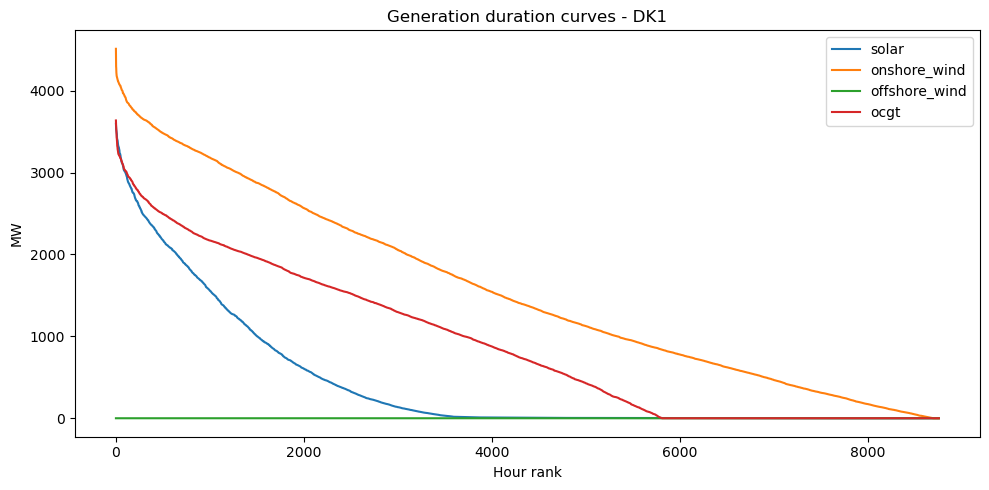

In [14]:
# Duration curves
plt.figure(figsize=(10, 5))

for tech in ["solar", "onshore_wind", "offshore_wind", "ocgt"]:
    dispatch[tech].sort_values(ascending=False).reset_index(drop=True).plot(label=tech)

plt.title("Generation duration curves - DK1")
plt.xlabel("Hour rank")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()

plt.savefig("Figures/duration_curves.png", dpi=300, bbox_inches="tight")

plt.show()

## TASK B

In [15]:
# Task B: Sensitivity to interannual weather variability
# Weather years: 2020-2025

df_weather = pd.read_csv(
    "Data/ProductionConsumptionSettlement_taskB.csv",
    sep=";",
    decimal=","
)

df_weather["HourUTC"] = pd.to_datetime(df_weather["HourUTC"], utc=True, errors="coerce")
df_weather["HourUTC"] = df_weather["HourUTC"].dt.tz_convert(None)
df_weather = df_weather.dropna(subset=["HourUTC"])
df_weather = df_weather.set_index("HourUTC").sort_index()

print("Min timestamp:", df_weather.index.min())
print("Max timestamp:", df_weather.index.max())
print("\nRows per year:")
print(df_weather.index.year.value_counts().sort_index())

# Fixed demand from Task A
snapshots = pd.date_range("2025-01-01 00:00", "2025-12-31 23:00", freq="h")
demand_fixed = load_dk1.reindex(snapshots).ffill().fillna(0).astype("float64")

# Helper function
def make_profile(series):
    series = pd.to_numeric(series, errors="coerce").fillna(0.0)
    max_val = series.max()
    if max_val <= 0:
        raise ValueError(f"{series.name} has no positive values.")
    return series / max_val

# Weather years to test
weather_years = [2020, 2021, 2022, 2023, 2024, 2025]

# Run model for each weather year
results = []

for year in weather_years:
    print(f"\nRunning optimization for weather year {year}...")

    # Filter by year
    df_year = df_weather[df_weather.index.year == year].copy()

    if df_year.empty:
        print(f"Skipping {year}: no data")
        continue

    print(f"Raw rows in {year}: {len(df_year)}")

    # Build full hourly index for that weather year
    full_index = pd.date_range(
        f"{year}-01-01 00:00",
        f"{year}-12-31 23:00",
        freq="h"
    )

    # Aggregate in case of duplicate timestamps
    df_year = df_year.groupby(df_year.index).first()

    # Reindex to full year
    df_year = df_year.reindex(full_index)

    # Build renewable generation series
    onshore_gen = (
        pd.to_numeric(df_year["OnshoreWindLt50kW_MWh"], errors="coerce").fillna(0)
        + pd.to_numeric(df_year["OnshoreWindGe50kW_MWh"], errors="coerce").fillna(0)
    )

    offshore_gen = (
        pd.to_numeric(df_year["OffshoreWindLt100MW_MWh"], errors="coerce").fillna(0)
        + pd.to_numeric(df_year["OffshoreWindGe100MW_MWh"], errors="coerce").fillna(0)
    )

    solar_gen = (
        pd.to_numeric(df_year["SolarPowerLt10kW_MWh"], errors="coerce").fillna(0)
        + pd.to_numeric(df_year["SolarPowerGe10Lt40kW_MWh"], errors="coerce").fillna(0)
        + pd.to_numeric(df_year["SolarPowerGe40kW_MWh"], errors="coerce").fillna(0)
    )

    # Make availability profiles
    try:
        solar_cf = make_profile(solar_gen)
        onshore_cf = make_profile(onshore_gen)
        offshore_cf = make_profile(offshore_gen)
    except ValueError as e:
        print(f"Skipping {year}: {e}")
        continue

    # If leap year, trim to 8760 so it matches fixed 2025 demand
    if len(full_index) == 8784:
        solar_cf = solar_cf.iloc[:8760]
        onshore_cf = onshore_cf.iloc[:8760]
        offshore_cf = offshore_cf.iloc[:8760]

    # Reset index to generic 2025 snapshots
    solar_cf.index = snapshots
    onshore_cf.index = snapshots
    offshore_cf.index = snapshots

    solar_cf = solar_cf.astype("float64")
    onshore_cf = onshore_cf.astype("float64")
    offshore_cf = offshore_cf.astype("float64")
    # Build model
    n = pypsa.Network()
    n.set_snapshots(snapshots)

    n.add("Carrier", "AC")
    n.add("Bus", "DK1", carrier="AC")

    n.add(
        "Load",
        "DK1_load",
        bus="DK1",
        p_set=demand_fixed
    )

    n.add(
        "Generator",
        "solar",
        bus="DK1",
        p_nom_extendable=True,
        p_max_pu=solar_cf,
        capital_cost=float(solar_annualized_cost),
        marginal_cost=float(solar_marginal_cost)
    )

    n.add(
        "Generator",
        "onshore_wind",
        bus="DK1",
        p_nom_extendable=True,
        p_max_pu=onshore_cf,
        capital_cost=float(onshore_annualized_cost),
        marginal_cost=float(onshore_marginal_cost)
    )

    n.add(
        "Generator",
        "offshore_wind",
        bus="DK1",
        p_nom_extendable=True,
        p_max_pu=offshore_cf,
        capital_cost=float(offshore_annualized_cost),
        marginal_cost=float(offshore_marginal_cost)
    )

    n.add(
        "Generator",
        "ocgt",
        bus="DK1",
        p_nom_extendable=True,
        capital_cost=float(ocgt_annualized_cost),
        marginal_cost=float(ocgt_marginal_cost),
        efficiency=float(ocgt_efficiency)
    )
    

    # Force numeric dtypes
    n.loads_t.p_set = n.loads_t.p_set.astype("float64")
    n.generators_t.p_max_pu = n.generators_t.p_max_pu.astype("float64")
    for col in ["capital_cost", "marginal_cost", "efficiency"]:
        if col in n.generators.columns:
            n.generators[col] = pd.to_numeric(n.generators[col], errors="coerce").astype("float64")

    # Optimize
    n.optimize()

    # Save capacities
    gen_cap = n.generators["p_nom_opt"].copy()
    cap = pd.concat([gen_cap])
    cap.name = year
    results.append(cap)

# Collect results
results_df = pd.DataFrame(results)
results_df.index.name = "weather_year"

print("\nOptimal capacities by weather year (MW):")
print(results_df)

# Mean and variability
mean_caps = results_df.mean()
std_caps = results_df.std()

summary_df = pd.DataFrame({
    "mean_capacity_MW": mean_caps,
    "std_capacity_MW": std_caps
})

print("\nAverage capacity and variability (MW):")
print(summary_df)

Min timestamp: 2019-12-31 23:00:00
Max timestamp: 2025-12-31 22:00:00

Rows per year:
HourUTC
2019       1
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    8759
Name: count, dtype: int64

Running optimization for weather year 2020...
Raw rows in 2020: 8784


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 653.17it/s]
INFO:linopy.io: Writing time: 0.03s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-fi2zmzko has 78844 rows; 35044 cols; 135918 nonzeros
Coefficient ranges:
  Matrix  [5e-07, 1e+00]
  Cost    [1e+02, 3e+05]
  Bound   [0e+00, 0e+00]
  RHS     [2e+03, 5e+03]
Presolving model
39551 rows, 30795 cols, 92376 nonzeros  0s
Dependent equations search running on 8757 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
39551 rows, 30795 cols, 92376 nonzeros  0s
Presolve reductions: rows 39551(-39293); columns 30795(-4249); nonzeros 92376(-43542) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 2.55e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      29314     2.5466612009e+09 Pr: 0(0) 0.7s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-fi2zmzko
Model status        : Optimal
Simplex   iterations: 29314
Objective value     :  2.5466612009e+09
P-D objective error :  1.7787811745e-15
HiGHS run time      :          0.72

Running optimization for weather year 2021...
Raw rows in 2021: 8760


...

      33079     2.6550728435e+09 Pr: 0(0); Du: 0(1.1244e-09) 0.9s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-nyv7kksf
Model status        : Optimal
Simplex   iterations: 33079
Objective value     :  2.6550728435e+09
P-D objective error :  1.9755423103e-15
HiGHS run time      :          0.90

Running optimization for weather year 2025...
Raw rows in 2025: 8759


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 701.56it/s]
INFO:linopy.io: Writing time: 0.02s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-gx3kmuxw has 78844 rows; 35044 cols; 140157 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 1e+00]
  Cost    [1e+02, 3e+05]
  Bound   [0e+00, 0e+00]
  RHS     [2e+03, 5e+03]
Presolving model
43792 rows, 35036 cols, 105097 nonzeros  0s
Dependent equations search running on 8759 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
40895 rows, 35036 cols, 99304 nonzeros  0s
Presolve reductions: rows 40895(-37949); columns 35036(-8); nonzeros 99304(-40853) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     1.2602314571e+08 Pr: 8759(9.77059e+06) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 2.57e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      32553     2.5672925595e+09 Pr: 0(0); Du: 0(3.58946e-11) 1.6s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-gx3kmuxw
Model status        : Optimal
Simplex   iterations: 32553
Objective value     :  2.5672925595e+09
P-D objective error :  3.1575021155e-15
HiGHS run time      :          1.60

Optimal capacities by weather year (MW):
name                solar  onshore_wind  offshore_wind         ocgt
weather_year                                                       
2020          3728.714001   4466.795561    1451.479000  3602.000445
2021          3964.371324   6914.404980      -0.000000  4217.942561
2022          3809.767567   5244.215376     801.069271  3681.652581
2023          3829.251666   6426.432537      -0.000000  3693.623776
2024          4023.189201   6347.775808      -0.000000  4525.077411
2025          3949.711653   6775.177498      -0.000000  3636.422709

Average capacity and variability (MW):
       

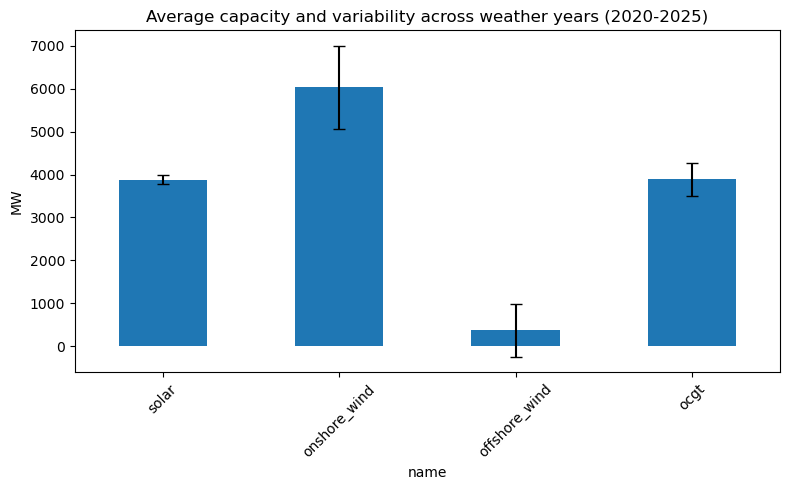

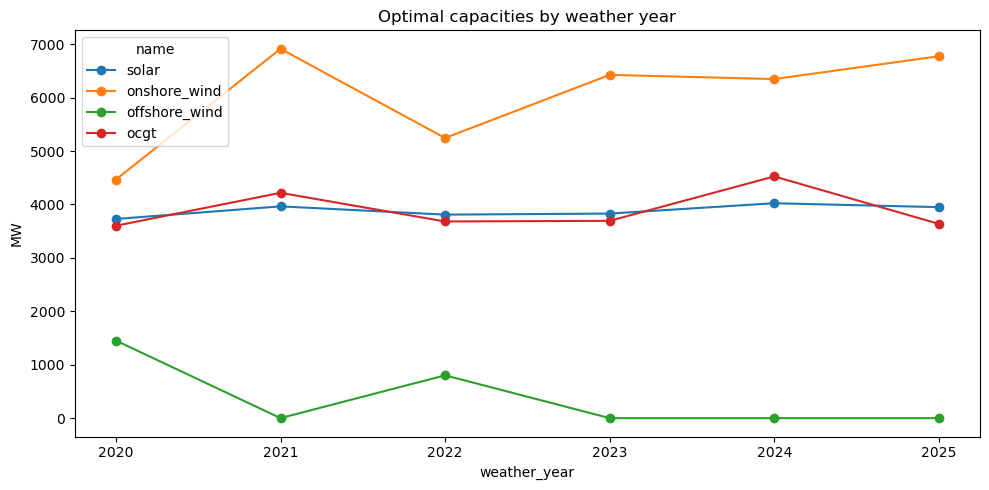

In [16]:
# Plot average capacity with variability
plt.figure(figsize=(8, 5))

mean_caps.plot(
    kind="bar",
    yerr=std_caps,
    capsize=4
)

plt.ylabel("MW")
plt.title("Average capacity and variability across weather years (2020-2025)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Figures/capacity_mean_variability.png", dpi=300, bbox_inches="tight")

plt.show()


# Plot all capacities by weather year
results_df.plot(marker="o", figsize=(10, 5))

plt.ylabel("MW")
plt.title("Optimal capacities by weather year")
plt.tight_layout()

plt.savefig("Figures/capacities_by_year.png", dpi=300, bbox_inches="tight")

plt.show()

## Task C

In [17]:
#Task c - Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration.

df_weather_c = pd.read_csv(
    "Data/ProductionConsumptionSettlement_taskC.csv",
    sep=";",
    decimal=","
)

df_weather_c["HourUTC"] = pd.to_datetime(df_weather_c["HourUTC"], utc=True, errors="coerce")
df_weather_c["HourUTC"] = df_weather_c["HourUTC"].dt.tz_convert(None)
df_weather_c = df_weather_c.dropna(subset=["HourUTC"])
df_weather_c = df_weather_c.set_index("HourUTC").sort_index()

print("Min timestamp:", df_weather_c.index.min())
print("Max timestamp:", df_weather_c.index.max())
print("\nRows per year:")
print(df_weather_c.index.year.value_counts().sort_index())

# Fixed demand from Task A
snapshots = pd.date_range("2025-01-01 00:00", "2025-12-31 23:00", freq="h")
demand_fixed = load_dk1.reindex(snapshots).ffill().fillna(0).astype("float64")

# Helper function
def make_profile(series):
    series = pd.to_numeric(series, errors="coerce").fillna(0.0)
    max_val = series.max()
    if max_val <= 0:
        raise ValueError(f"{series.name} has no positive values.")
    return series / max_val

# Weather years to test
weather_years = [2020, 2021, 2022, 2023, 2024, 2025]

# Run model for each weather year
results = []

for year in weather_years:
    print(f"\nRunning optimization for weather year {year}...")

    # Filter by year
    df_year = df_weather_c[df_weather_c.index.year == year].copy()

    if df_year.empty:
        print(f"Skipping {year}: no data")
        continue

    print(f"Raw rows in {year}: {len(df_year)}")

    # Build full hourly index for that weather year
    full_index = pd.date_range(
        f"{year}-01-01 00:00",
        f"{year}-12-31 23:00",
        freq="h"
    )

    # Aggregate in case of duplicate timestamps
    df_year = df_year.groupby(df_year.index).first()

    # Reindex to full year
    df_year = df_year.reindex(full_index)

    # Build renewable generation series
    onshore_gen = (
        pd.to_numeric(df_year["OnshoreWindLt50kW_MWh"], errors="coerce").fillna(0)
        + pd.to_numeric(df_year["OnshoreWindGe50kW_MWh"], errors="coerce").fillna(0)
    )

    offshore_gen = (
        pd.to_numeric(df_year["OffshoreWindLt100MW_MWh"], errors="coerce").fillna(0)
        + pd.to_numeric(df_year["OffshoreWindGe100MW_MWh"], errors="coerce").fillna(0)
    )

    solar_gen = (
        pd.to_numeric(df_year["SolarPowerLt10kW_MWh"], errors="coerce").fillna(0)
        + pd.to_numeric(df_year["SolarPowerGe10Lt40kW_MWh"], errors="coerce").fillna(0)
        + pd.to_numeric(df_year["SolarPowerGe40kW_MWh"], errors="coerce").fillna(0)
    )

    # Make availability profiles
    try:
        solar_cf = make_profile(solar_gen)
        onshore_cf = make_profile(onshore_gen)
        offshore_cf = make_profile(offshore_gen)
    except ValueError as e:
        print(f"Skipping {year}: {e}")
        continue

    # If leap year, trim to 8760 so it matches fixed 2025 demand
    if len(full_index) == 8784:
        solar_cf = solar_cf.iloc[:8760]
        onshore_cf = onshore_cf.iloc[:8760]
        offshore_cf = offshore_cf.iloc[:8760]

    # Reset index to generic 2025 snapshots
    solar_cf.index = snapshots
    onshore_cf.index = snapshots
    offshore_cf.index = snapshots

    solar_cf = solar_cf.astype("float64")
    onshore_cf = onshore_cf.astype("float64")
    offshore_cf = offshore_cf.astype("float64")
    # Build model
    n = pypsa.Network()
    n.set_snapshots(snapshots)

    n.add("Carrier", "AC")
    n.add("Bus", "DK1", carrier="AC")

    n.add(
        "Load",
        "DK1_load",
        bus="DK1",
        p_set=demand_fixed
    )

    n.add(
        "Generator",
        "solar",
        bus="DK1",
        p_nom_extendable=True,
        p_max_pu=solar_cf,
        capital_cost=float(solar_annualized_cost),
        marginal_cost=float(solar_marginal_cost)
    )

    n.add(
        "Generator",
        "onshore_wind",
        bus="DK1",
        p_nom_extendable=True,
        p_max_pu=onshore_cf,
        capital_cost=float(onshore_annualized_cost),
        marginal_cost=float(onshore_marginal_cost)
    )

    n.add(
        "Generator",
        "offshore_wind",
        bus="DK1",
        p_nom_extendable=True,
        p_max_pu=offshore_cf,
        capital_cost=float(offshore_annualized_cost),
        marginal_cost=float(offshore_marginal_cost)
    )

    n.add(
        "Generator",
        "ocgt",
        bus="DK1",
        p_nom_extendable=True,
        capital_cost=float(ocgt_annualized_cost),
        marginal_cost=float(ocgt_marginal_cost),
        efficiency=float(ocgt_efficiency)
    )
    
    n.add(
        "StorageUnit",
        "battery",
        bus="DK1",
        p_nom_extendable=True,
        max_hours=battery_duration,
        efficiency_store=battery_inverter_efficiency_store,
        efficiency_dispatch=battery_inverter_efficiency_dispatch,
        capital_cost=float(battery_annualized_cost),
        marginal_cost=float(battery_marginal_cost),
        cyclic_state_of_charge=True
    )

    # Force numeric dtypes
    n.loads_t.p_set = n.loads_t.p_set.astype("float64")
    n.generators_t.p_max_pu = n.generators_t.p_max_pu.astype("float64")
    for col in ["capital_cost", "marginal_cost", "efficiency"]:
        if col in n.generators.columns:
            n.generators[col] = pd.to_numeric(n.generators[col], errors="coerce").astype("float64")

    # Optimize
    n.optimize()

    # Calculate battery power and energy capacity
    battery_power = n.storage_units.at["battery", "p_nom_opt"]
    battery_energy = battery_power * n.storage_units.at["battery", "max_hours"]
    
    # Save generator capacities
    gen_cap = n.generators["p_nom_opt"].copy()

    # Save storage power capacity
    storage_cap = n.storage_units["p_nom_opt"].copy()

    # Combine both into one Series
    cap = pd.concat([gen_cap, storage_cap])
    cap.name = year
    results.append(cap)

# Collect results
results_df = pd.DataFrame(results)
results_df.index.name = "weather_year"

print(f"Battery power capacity: {battery_power:.2f} MW")
print(f"Battery energy capacity: {battery_energy:.2f} MWh")

print("\nOptimal capacities by weather year (MW):")
print(results_df)

# Mean and variability
mean_caps = results_df.mean()
std_caps = results_df.std()

summary_df = pd.DataFrame({
    "mean_capacity_MW": mean_caps,
    "std_capacity_MW": std_caps
})

print("\nAverage capacity and variability (MW) with battery:")
print(summary_df)

Min timestamp: 2019-12-31 23:00:00
Max timestamp: 2025-12-31 22:00:00

Rows per year:
HourUTC
2019       1
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    8759
Name: count, dtype: int64

Running optimization for weather year 2020...
Raw rows in 2020: 8784


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 615.08it/s]
INFO:linopy.io: Writing time: 0.07s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-89cqcmup has 140165 rows; 61325 cols; 267319 nonzeros
Coefficient ranges:
  Matrix  [5e-07, 4e+00]
  Cost    [1e+02, 3e+05]
  Bound   [0e+00, 0e+00]
  RHS     [2e+03, 5e+03]
Presolving model
74594 rows, 57079 cols, 197502 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
74594 rows, 57079 cols, 197502 nonzeros  0s
Presolve reductions: rows 74594(-65571); columns 57079(-4246); nonzeros 197502(-69817) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(4.14251e+06) 0.1s
      58067     2.5091523786e+09 Pr: 3846(973840); Du: 0(7.04686e-08) 5.2s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140165 duals
Objective: 2.52e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      62395     2.5188475307e+09 Pr: 0(0); Du: 0(2.84217e-14) 5.8s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-89cqcmup
Model status        : Optimal
Simplex   iterations: 62395
Objective value     :  2.5188475307e+09
P-D objective error :  3.2182303967e-15
HiGHS run time      :          5.80

Running optimization for weather year 2021...
Raw rows in 2021: 8760


...

      65503     2.6069085243e+09 Pr: 0(0); Du: 0(2.9195e-11) 5.5s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-5mmv3sug
Model status        : Optimal
Simplex   iterations: 65503
Objective value     :  2.6069085243e+09
P-D objective error :  1.3718466346e-15
HiGHS run time      :          5.49

Running optimization for weather year 2025...
Raw rows in 2025: 8759


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 829.08it/s]
INFO:linopy.io: Writing time: 0.05s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-2fma7uw4 has 140165 rows; 61325 cols; 271558 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 4e+00]
  Cost    [1e+02, 3e+05]
  Bound   [0e+00, 0e+00]
  RHS     [2e+03, 5e+03]
Presolving model
78833 rows, 61318 cols, 210219 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
78833 rows, 61318 cols, 210219 nonzeros  0s
Presolve reductions: rows 78833(-61332); columns 61318(-7); nonzeros 210219(-61339) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(1.08826e+07) 0.1s
      60698     2.5154524238e+09 Pr: 3215(1.2625e+06); Du: 0(1.10282e-07) 5.2s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140165 duals
Objective: 2.54e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      66982     2.5399114831e+09 Pr: 0(0); Du: 0(2.79337e-10) 5.9s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-2fma7uw4
Model status        : Optimal
Simplex   iterations: 66982
Objective value     :  2.5399114831e+09
P-D objective error :  1.1264262427e-15
HiGHS run time      :          5.98
Battery power capacity: 792.74 MW
Battery energy capacity: 3170.95 MWh

Optimal capacities by weather year (MW):
name                solar  onshore_wind  offshore_wind         ocgt  \
weather_year                                                          
2020          4204.120063   5028.653444    1095.950171  3087.023119   
2021          4356.331408   6892.066197      -0.000000  3616.462165   
2022          4392.214778   5848.614539     375.586194  3182.142539   
2023          4432.778494   6336.935503      -0.000000  3233.273969   
2024          4615.039795   6333.296850      -0.000000  3353.247767   
2025          4524.6282

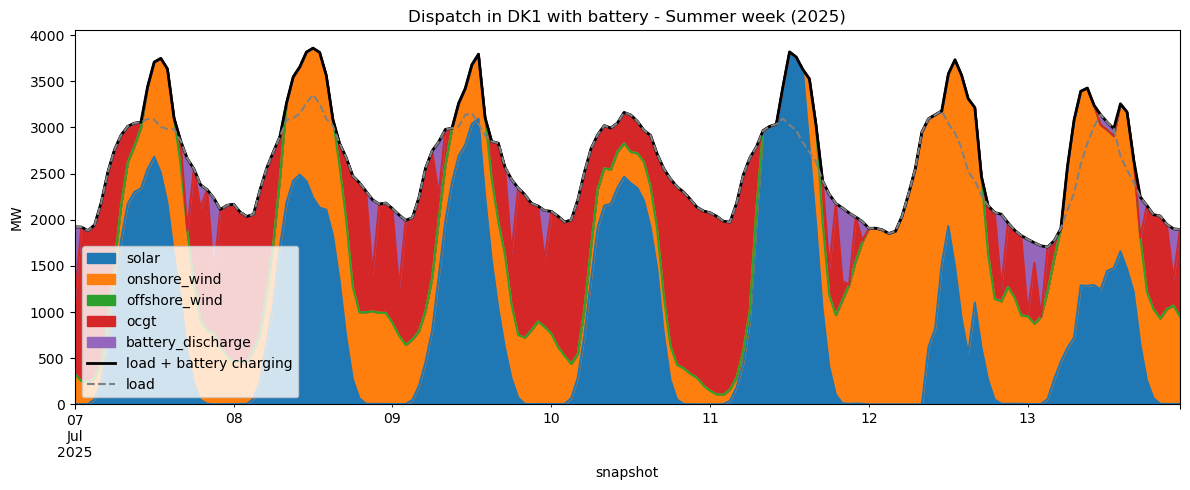

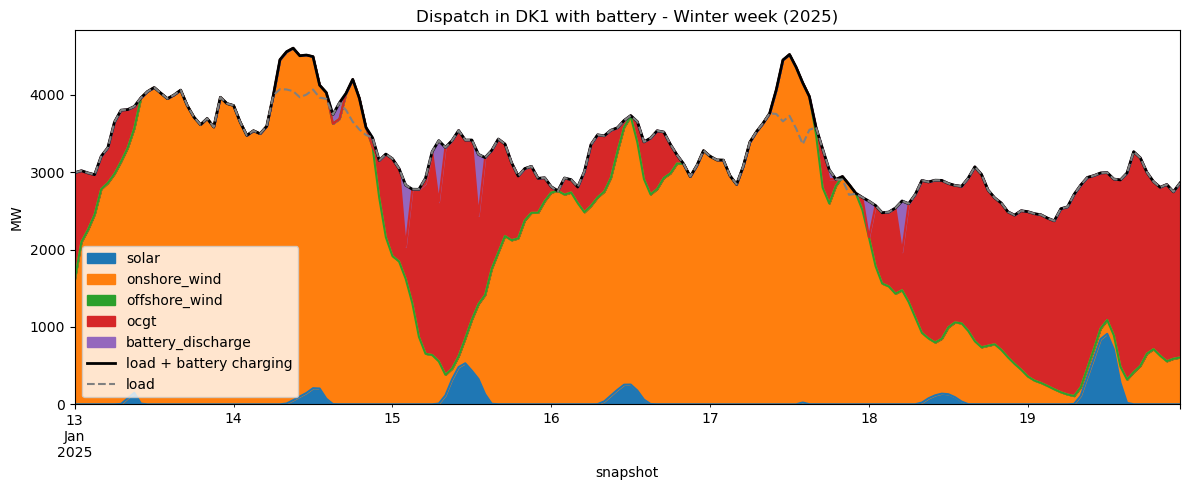

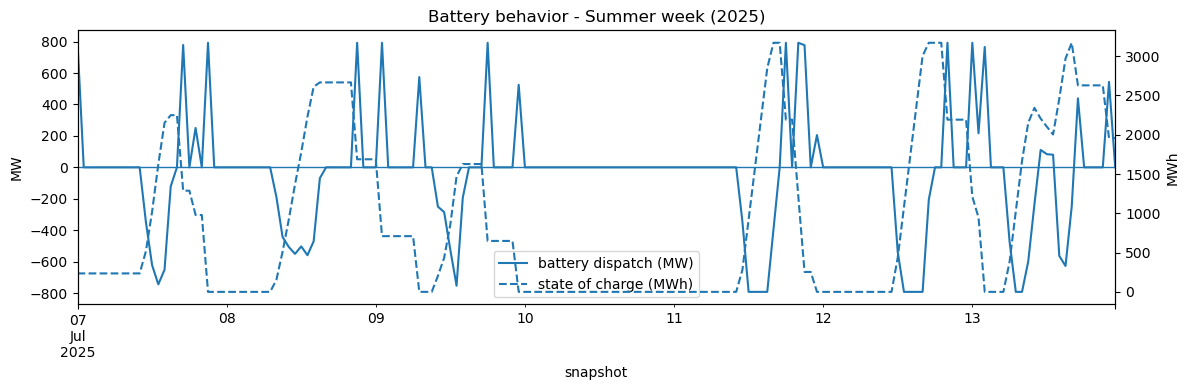

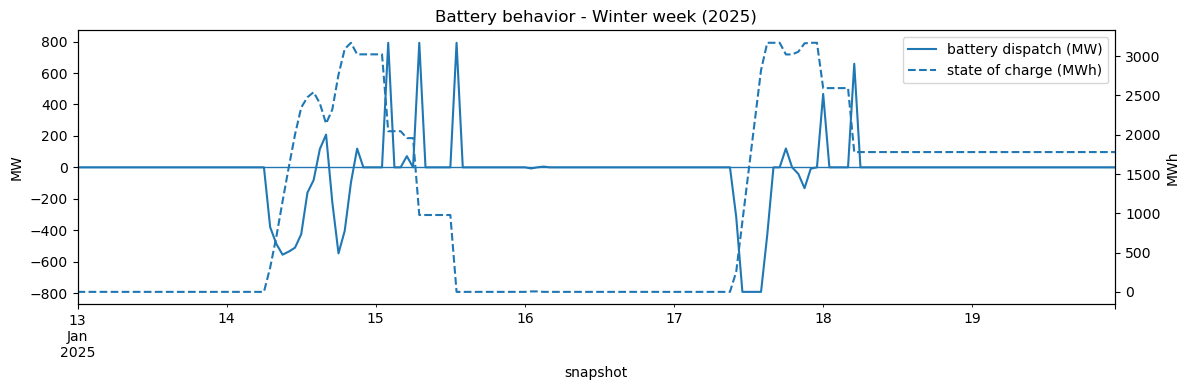

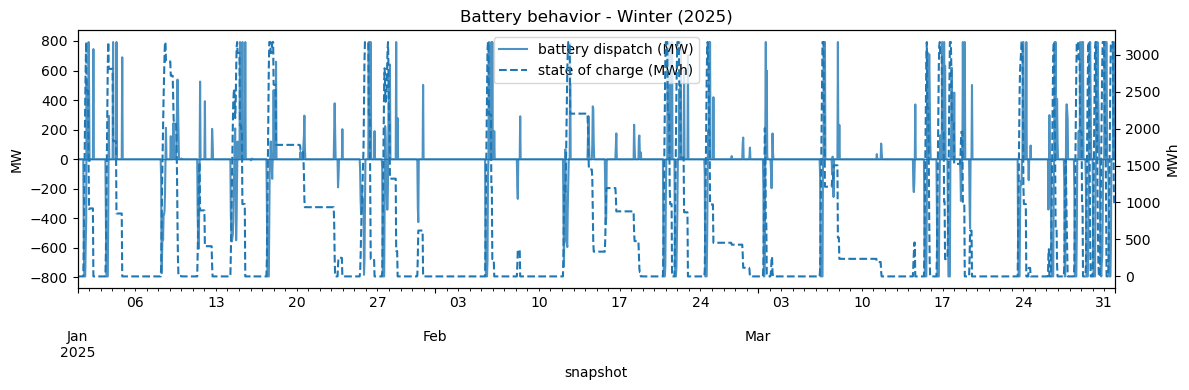

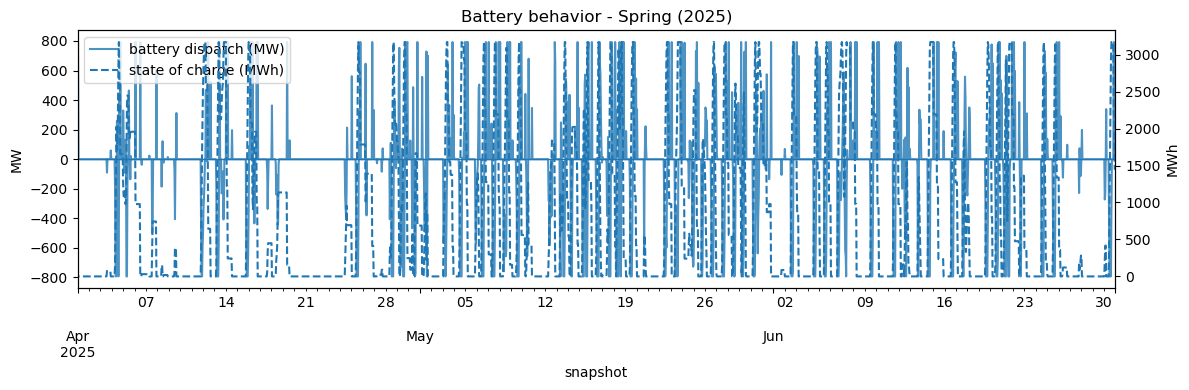

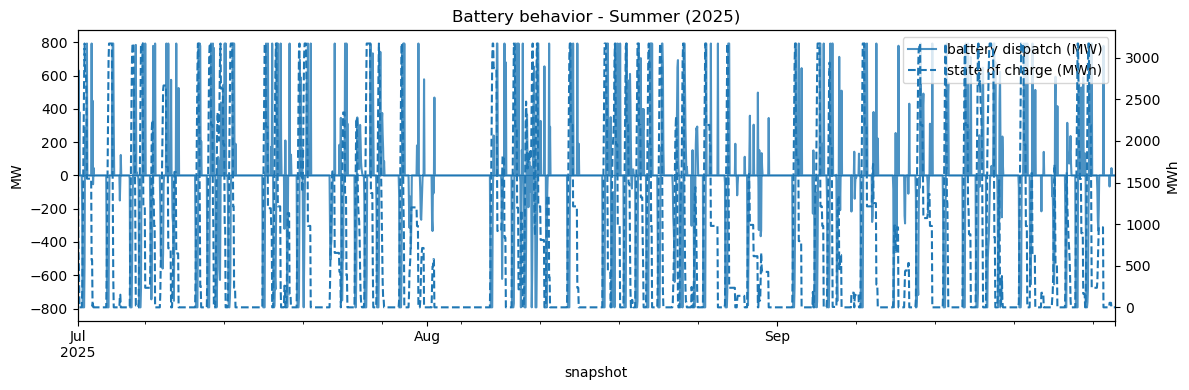

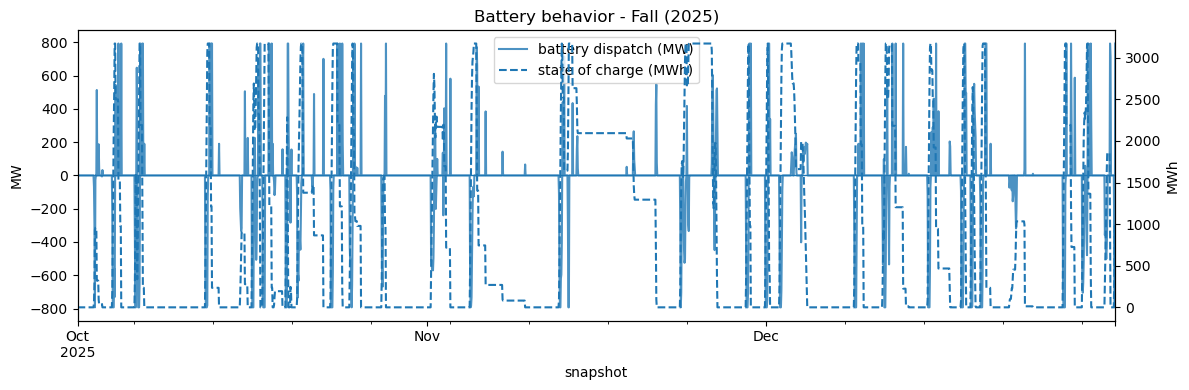

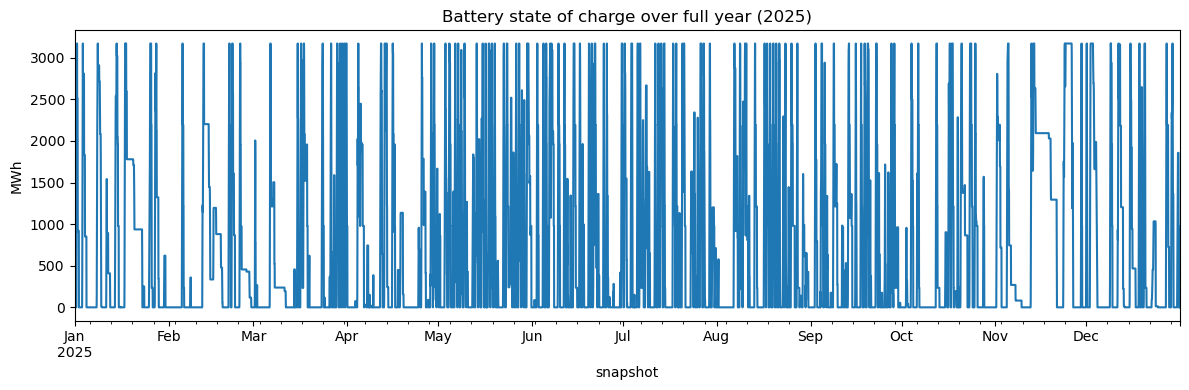

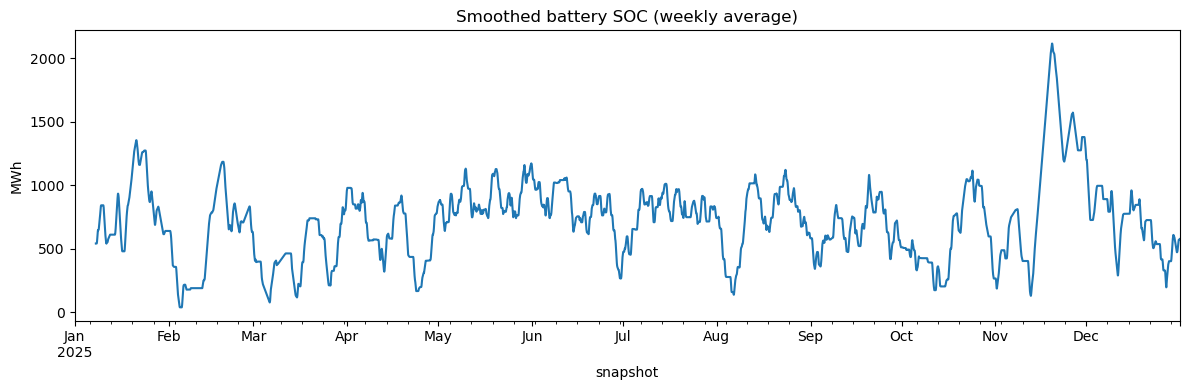

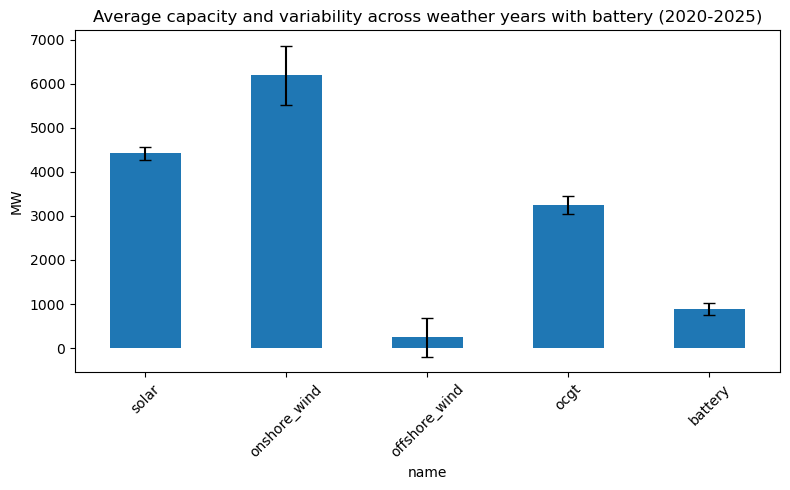

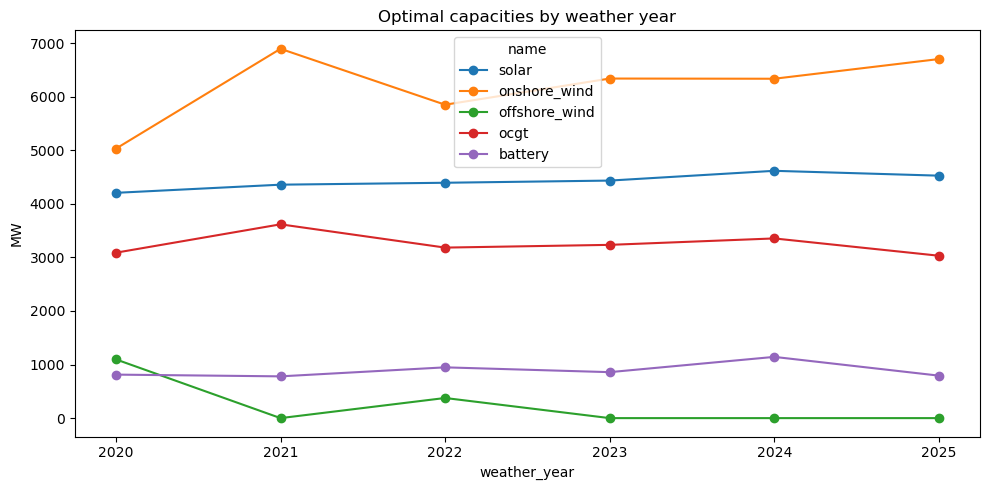

In [18]:
plot_year = 2025
summer_week = slice("2025-07-07", "2025-07-13 23:00")
winter_week = slice("2025-01-13", "2025-01-19 23:00")
winter = slice("2025-01-01", "2025-03-31 23:00")
spring = slice("2025-04-01", "2025-06-30 23:00")
summer = slice("2025-07-01", "2025-09-30 23:00")
fall   = slice("2025-10-01", "2025-12-31 23:00")

if year == plot_year:
    dispatch_c = n.generators_t.p[["solar", "onshore_wind", "offshore_wind", "ocgt"]].copy()
    battery_dispatch_c = n.storage_units_t.p["battery"].copy()
    battery_soc_c = n.storage_units_t.state_of_charge["battery"].copy()
    load_c = n.loads_t.p["DK1_load"].copy()

battery_discharge = battery_dispatch_c.clip(lower=0)
battery_charge = -battery_dispatch_c.clip(upper=0)

battery_discharge = battery_dispatch_c.clip(lower=0)
battery_charge = -battery_dispatch_c.clip(upper=0)

dispatch_plot = dispatch_c.copy()
dispatch_plot["battery_discharge"] = battery_discharge

effective_load = load_c + battery_charge

# Summer week
ax = dispatch_plot.loc[summer_week].plot.area(figsize=(12, 5))

effective_load.loc[summer_week].plot(
    ax=ax, color="black", linewidth=2, label="load + battery charging"
)

load_c.loc[summer_week].plot(
    ax=ax, color="grey", linestyle="--", linewidth=1.5, label="load"
)

plt.title(f"Dispatch in DK1 with battery - Summer week ({plot_year})")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.savefig("Figures/dispatch_summer_battery_split.png", dpi=300, bbox_inches="tight")
plt.show()

# Winter week
ax = dispatch_plot.loc[winter_week].plot.area(figsize=(12, 5))

effective_load.loc[winter_week].plot(
    ax=ax, color="black", linewidth=2, label="load + battery charging"
)

load_c.loc[winter_week].plot(
    ax=ax, color="grey", linestyle="--", linewidth=1.5, label="load"
)

plt.title(f"Dispatch in DK1 with battery - Winter week ({plot_year})")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.savefig("Figures/dispatch_winter_battery_split.png", dpi=300, bbox_inches="tight")
plt.show()

# Summer SOC and behavior
fig, ax1 = plt.subplots(figsize=(12, 4))

# Battery dispatch (left axis)
battery_dispatch_c.loc[summer_week].plot(
    ax=ax1, label="battery dispatch (MW)"
)
ax1.axhline(0, linewidth=1)
ax1.set_ylabel("MW")

# Second axis for SOC
ax2 = ax1.twinx()

battery_soc_c.loc[summer_week].plot(
    ax=ax2, linestyle="--", label="state of charge (MWh)"
)
ax2.set_ylabel("MWh")

# Title and layout
plt.title(f"Battery behavior - Summer week ({plot_year})")

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.tight_layout()
plt.savefig("Figures/battery_behavior_summer.png", dpi=300, bbox_inches="tight")
plt.show()


# Winter SOC and behavior
fig, ax1 = plt.subplots(figsize=(12, 4))

battery_dispatch_c.loc[winter_week].plot(
    ax=ax1, label="battery dispatch (MW)"
)
ax1.axhline(0, linewidth=1)
ax1.set_ylabel("MW")

ax2 = ax1.twinx()

battery_soc_c.loc[winter_week].plot(
    ax=ax2, linestyle="--", label="state of charge (MWh)"
)
ax2.set_ylabel("MWh")

plt.title(f"Battery behavior - Winter week ({plot_year})")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.tight_layout()
plt.savefig("Figures/battery_behavior_winter.png", dpi=300, bbox_inches="tight")
plt.show()


def plot_battery_season(season_slice, season_name):
    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Dispatch
    battery_dispatch_c.loc[season_slice].plot(
        ax=ax1, label="battery dispatch (MW)", alpha=0.8
    )
    ax1.axhline(0, linewidth=1)
    ax1.set_ylabel("MW")

    # SOC on second axis
    ax2 = ax1.twinx()
    battery_soc_c.loc[season_slice].plot(
        ax=ax2, linestyle="--", label="state of charge (MWh)"
    )
    ax2.set_ylabel("MWh")

    plt.title(f"Battery behavior - {season_name} ({plot_year})")

    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

    plt.tight_layout()
    plt.savefig(f"Figures/battery_{season_name.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_battery_season(winter, "Winter")
plot_battery_season(spring, "Spring")
plot_battery_season(summer, "Summer")
plot_battery_season(fall, "Fall")

#SOC full year 2025
plt.figure(figsize=(12, 4))

battery_soc_c.plot()

plt.title("Battery state of charge over full year (2025)")
plt.ylabel("MWh")
plt.tight_layout()
plt.savefig("Figures/battery_soc_full_year.png", dpi=300, bbox_inches="tight")
plt.show()

# Rolling average
soc_smooth = battery_soc_c.rolling(24*7).mean()  # weekly smoothing

plt.figure(figsize=(12, 4))
soc_smooth.plot()

plt.title("Smoothed battery SOC (weekly average)")
plt.ylabel("MWh")
plt.tight_layout()
plt.show()

# Plot average capacity with variability and battery
plt.figure(figsize=(8, 5))

mean_caps.plot(
    kind="bar",
    yerr=std_caps,
    capsize=4
)

plt.ylabel("MW")
plt.title("Average capacity and variability across weather years with battery (2020-2025)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Figures/capacity_mean_variability_battery.png", dpi=300, bbox_inches="tight")

plt.show()


# Plot all capacities by weather year
results_df.plot(marker="o", figsize=(10, 5))

plt.ylabel("MW")
plt.title("Optimal capacities by weather year")
plt.tight_layout()

plt.savefig("Figures/capacities_by_year_with_battery.png", dpi=300, bbox_inches="tight")

plt.show()

## Task D

The Interconections DK2, Norway - Norwegian South-West - (NO2) and Germany - northern Germany - (DE) are choosen as country connections for this part of the assignment. Due to the realistically given connection of DK2 and DE the closed circle is also fullfiled (DK1->DK2->DE->DK1).

All lines are modeled as HVAC lines with 400 kV and a unitary reactance of x=0.1 as given in the assignment.

The following Capacities are assumed for these interconections, based on the actuall data given on Energinet.

DK1 <-> NO2:    1700 MW
DK1 <-> DE:     2500 MW
DK1 <-> DK2:    600  MW
DK2 <-> DE:     600  MW

The system is optimized using linearised powerflow.

The capacities of the connected regions are defined using the PyPSA-Europe Data.

In [19]:
# defining the cpacities of the connected regions:
con_cap = {
    "DK2": {
        "solar": 1200,      # MW
        "onwind": 1100,     # MW
        "offwind": 1500,    # MW
        "ocgt": 1600        # MW (thermal)
    },
    "DE": {
        # Scaled-down from actual ENTSO-E capacities to represent northern Germany (~0.1× scaling)
        "solar": 7000,
        "onwind": 6000,
        "offwind": 900,
        "ocgt": 5000
    },
    "NO2": {
        "onwind": 2000,     # MW
        "hydro": 14000      # MW  (reservoir + RoR)
    }
}


# Create the network
n = pypsa.Network()
n.set_snapshots(snapshots)

# Buses for each country

# DK1 load (fixed)
n.add("Load", "DK1_load", bus="DK1", p_set=demand_fixed)




# adding generators for connected regions
''' This tells the model:
    Neighbours have a fixed generation capacity
    They produce power when economical
    They can export to DK1 over interconnectors
'''

for country, techs in con_cap.items():
    for tech, cap in techs.items():

        carrier = tech  # e.g., "solar", "onwind", "hydro", etc.

        # Flat profile for hydro, realistic p_max_pu needed for RES
        if carrier == "hydro":
            p_max_pu = 1.0
        else:
            # Use DK1 profiles for now, or load per-country profiles if available
            p_max_pu = 1.0

        n.add(
            "Generator",
            f"{country}_{tech}",
            bus=country,
            p_nom=cap,                  # fixed installed capacity
            p_nom_extendable=False,
            marginal_cost=0.0,)        # neighbours not


# Task D – Build multi-bus network:
nD = pypsa.Network()
nD.set_snapshots(snapshots)   # reuse the 2025 hourly index

# Add buses for each region
for bus in ["DK1", "DK2", "DE", "NO2"]:
    nD.add("Bus", bus, carrier="AC")

#flat_profile = pd.Series(1.0, index=snapshots)  # full availabilit -- potenial bug fix, otherwise it can be deleted later
# Fixed capacity generators in neighbouring regions:
for country, techs in con_cap.items():
    for tech, cap in techs.items():

        carrier = tech  # can be used to set costs if needed

        # For now: simple flat availability (p_max_pu = 1)
        # Later you could use country-specific profiles if you want.
        if tech == "hydro":
            p_max_pu = 1.0
        else:
            p_max_pu = 1.0

        nD.add(
            "Generator",
            f"{country}_{tech}",
            bus=country,
            p_nom=cap,                  # fixed installed capacity
            p_nom_extendable=False,
            p_max_pu=p_max_pu,
            marginal_cost=0.0,          # we can refine this later
            capital_cost=0.0            # so that capacity is truly fixed
        )

# adding the load from task a:
nD.add("Load", "DK1_load",
       bus="DK1",
       p_set=demand_fixed)



Index(['DK1_load'], dtype='object', name='name')
Index(['DK2_solar'], dtype='object', name='name')
Index(['DK2_solar', 'DK2_onwind'], dtype='object', name='name')
Index(['DK2_solar', 'DK2_onwind', 'DK2_offwind'], dtype='object', name='name')
Index(['DK2_solar', 'DK2_onwind', 'DK2_offwind', 'DK2_ocgt'], dtype='object', name='name')
Index(['DK2_solar', 'DK2_onwind', 'DK2_offwind', 'DK2_ocgt', 'DE_solar'], dtype='object', name='name')
Index(['DK2_solar', 'DK2_onwind', 'DK2_offwind', 'DK2_ocgt', 'DE_solar',
       'DE_onwind'],
      dtype='object', name='name')
Index(['DK2_solar', 'DK2_onwind', 'DK2_offwind', 'DK2_ocgt', 'DE_solar',
       'DE_onwind', 'DE_offwind'],
      dtype='object', name='name')
Index(['DK2_solar', 'DK2_onwind', 'DK2_offwind', 'DK2_ocgt', 'DE_solar',
       'DE_onwind', 'DE_offwind', 'DE_ocgt'],
      dtype='object', name='name')
Index(['DK2_solar', 'DK2_onwind', 'DK2_offwind', 'DK2_ocgt', 'DE_solar',
       'DE_onwind', 'DE_offwind', 'DE_ocgt', 'NO2_onwind'],
     

DK1 Generators from previous task

In [20]:
# DK1 solar (extendable)
nD.add(
    "Generator",
    "solar_DK1",
    bus="DK1",
    p_nom_extendable=True,
    p_max_pu=solar_cf,
    capital_cost=solar_annualized_cost,
    marginal_cost=solar_marginal_cost
)

# DK1 onshore wind (extendable)
nD.add(
    "Generator",
    "onshore_wind_DK1",
    bus="DK1",
    p_nom_extendable=True,
    p_max_pu=onshore_cf,
    capital_cost=onshore_annualized_cost,
    marginal_cost=onshore_marginal_cost
)

# DK1 offshore wind (extendable)
nD.add(
    "Generator",
    "offshore_wind_DK1",
    bus="DK1",
    p_nom_extendable=True,
    p_max_pu=offshore_cf,
    capital_cost=offshore_annualized_cost,
    marginal_cost=offshore_marginal_cost
)

# DK1 OCGT (extendable)
nD.add(
    "Generator",
    "ocgt_DK1",
    bus="DK1",
    p_nom_extendable=True,
    capital_cost=ocgt_annualized_cost,
    marginal_cost=ocgt_marginal_cost,
    efficiency=ocgt_efficiency
)


Creating the HVAC Connections (400 kV, x=0.1):

In [21]:
# DK1 <-> NO2
nD.add(
    "Line",
    "DK1_NO2",
    bus0="DK1",
    bus1="NO2",
    x=0.1,
    s_nom=1700.0    # MW
)

# DK1 <-> DE
nD.add(
    "Line",
    "DK1_DE",
    bus0="DK1",
    bus1="DE",
    x=0.1,
    s_nom=2500.0    # MW
)

# DK1 <-> DK2
nD.add(
    "Line",
    "DK1_DK2",
    bus0="DK1",
    bus1="DK2",
    x=0.1,
    s_nom=600.0     # MW
)

# DK2 <-> DE
nD.add(
    "Line",
    "DK2_DE",
    bus0="DK2",
    bus1="DE",
    x=0.1,
    s_nom=600.0     # MW
)

#cleanup to get rid of the warnings:
nD.add("Carrier", "AC")
nD.set_snapshots(snapshots)

Optimising the model:

In [22]:
nD.optimize()

Index(['DK1_NO2', 'DK1_DE', 'DK1_DK2', 'DK2_DE'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 190.97it/s]
INFO:linopy.io: Writing time: 0.08s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-0l9dj3kc has 359164 rows; 157684 cols; 569397 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 1e+04]
  Cost    [1e+02, 3e+05]
  Bound   [0e+00, 0e+00]
  RHS     [6e+02, 1e+04]
Presolving model
78833 rows, 96357 cols, 227739 nonzeros  0s
61313 rows, 78837 cols, 185252 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
52553 rows, 70077 cols, 157659 nonzeros  0s
Presolve reductions: rows 52553(-306611); columns 70077(-87607); nonzeros 157659(-411738) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.2403030370e+00 Pr: 17520(6.62731e+07) 0.4s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 157684 primals, 359164 duals
Objective: 9.40e+07
Solver model: available
Solver message: Optimal



      43561     9.4011500287e+07 Pr: 0(0) 0.8s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-0l9dj3kc
Model status        : Optimal
Simplex   iterations: 43561
Objective value     :  9.4011500287e+07
P-D objective error :  2.2190503818e-15
HiGHS run time      :          0.90


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.


('ok', 'optimal')